# Assignment #1. Spectral approximations and operations.
In this assignment, you will develop fundamental routines for a spectral methods toolbox in
Python/Matlab/Julia that will be useful for later solving differential equations. A partial goal
is to develop your ability to perform ’computational thinking’ through mastering fundamental
concepts and linking theory to practical implementations to be able to explain gaps.
## Fourier Spectral Methods (Estimated effort: 2 weeks)
### subpart a)

We start by defining the target function $u(x)$ on the domain $x \in [0, 2]$.

In [9]:
import numpy as np

u = lambda x: 1 / (2 - np.cos(x * np.pi))

To find the exact continuous Fourier coefficients $\hat{u}_k$, we evaluate the standard integral:
$$
    \hat{u}_k = \frac{1}{2} \int_{0}^{2} u(x) e^{-i k \pi x} dx
$$
where we use the substitution $\theta = \pi x$ mapping our domain to a standard unit circle $[0, 2\pi]$. The integral is then;
$$
    \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{e^{-i k \theta}}{2-\cos(\theta)} d\theta
$$
We substitute $z = e^{i\theta}$ because we remember that Euler's formula is
$$
    e^{i\theta} = \cos(\theta) + i \sin(\theta)
$$
or for a negative angle $-\theta$
$$
    e^{-i\theta} = \cos(\theta) - i \sin(\theta)
$$
we can use this to find an expression for $\cos(\theta)$
\begin{align*}
    e^{i\theta} + e^{-i\theta} &= 2\cos(\theta) \\
    \cos(\theta) &= \frac{e^{i\theta} + e^{-i\theta}}{2} = \frac{z + z^{-1}}{2}
\end{align*}
we also want to convert $d\theta$ into $dz$. The derivative of $z$ wrt $\theta$ is $z' = \frac{dz}{d\theta} = (e^{i\theta})' = ie^{i\theta}$. We can rearrange it as
$$
    dz = ie^{i\theta}d\theta
$$
or
$$
    d\theta = \frac{dz}{ie^{i\theta}}
$$
and since $z = e^{i\theta}$, we instead say; $d\theta = \frac{dz}{iz}$. \
We substitute this back into our expression for $\hat{u}_k$, replacing $e^{-ik\theta}$ with $z^{-k}$, $\cos(\theta) = \frac{z + z^{-1}}{2}$, and $d\theta$ with $\frac{dz}{iz}$;
$$
    \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k}}{2 - \frac{z + z^{-1}}{2}} \frac{dz}{iz}
$$
We can simplify the denominator term as
$$
    2 - \frac{z + z^{-1}}{2} = \frac{4}{2} - \frac{z + z^{-1}}{2} = \frac{4 - z - z^{-1}}{2} = \frac{4 - z - \frac{1}{z}}{2} = \frac{4z - z^2 - 1}{2z}
$$
if we substitute this back into the formula we get
$$
     \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k}}{\frac{4z - z^2 - 1}{2z}} \frac{dz}{iz} = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k} \cdot 2z}{4z - z^2 - 1} \frac{dz}{iz} = \int_{0}^{2\pi} \frac{1 \cdot z^{-k} \cdot 2z}{2\pi \cdot (4z - z^2 - 1) \cdot iz} dz = \frac{1}{2\pi i} \int_{0}^{2\pi} \frac{2z^{-k}}{4z - z^2 - 1} dz
$$
from this we find recognize the denominator as a quadratic function and find its solutions as $z^2 - 4z + 1 = 0$. The solutions are $z_1, z_2 = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a};

\begin{align*}
    z_1 &= \frac{-(-4) + \sqrt{(-4)^2 - 4 \cdot 1 \cdot 1}}{2 \cdot 1} = \frac{4 + \sqrt{12}}{2} = \frac{4 + \sqrt{4} \cdot \sqrt{3}}{2} = 2 + \sqrt{3} \\
    z_2 &= \frac{-(-4) - \sqrt{(-4)^2 - 4 \cdot 1 \cdot 1}}{2 \cdot 1} = \frac{4 - \sqrt{12}}{2} = \frac{4 - \sqrt{4} \cdot \sqrt{3}}{2} = 2 - \sqrt{3} 
\end{align*}
As Cauchy's Residue Theorem only concern points within the unit circle $z_2$ is the only valid solution. For a fraction we can find the residue as $\text{Residue} = \frac{p(z_2)}{q'(z_2)}$;
$$
    \frac{2z_2^{-k}}{(4z_2 - z_2^2 - 1)'} = \frac{2z_2^{-k}}{4 - 2z_2}
$$
substituting $z_2 = 2 - \sqrt{3}$;
$$
    \frac{2(2 - \sqrt{3})^{-k}}{4 - 2(2 - \sqrt{3})} = \frac{2(2 - \sqrt{3})^{-k}}{4 - 4 + 2\sqrt{3}} = \frac{(2 - \sqrt{3})^{-k}}{\sqrt{3}}
$$
to fix the notation a little we use the fact that $(2 - \sqrt{3})(2 + \sqrt{3}) = 1$ can be rewritten as $2 - \sqrt{3} = \frac{1}{2 + \sqrt{3}} = (2 + \sqrt{3})^{-1}$. And since $((2 + \sqrt{3})^{-1})^{-k} = (2 + \sqrt{3})^k$, we have that $\hat{u}_k = \frac{(2 + \sqrt{3})^k}{\sqrt{3}}$ or as the given solution puts it;
$$
    \hat{u}_k = \frac{1}{\sqrt{3} (2 + \sqrt{3})^k}
$$
Since Fourier dictates that a symmetric functions coefficients must also be symmetric, $\hat{u}_k = \hat{u}_{-k}$, we replace $k$ with $|k|$ to handle both positive and negative $k$ correctly.
$$
    \hat{u}_k = \frac{1}{\sqrt{3} (2 + \sqrt{3})^{|k|}}
$$
To determine the asymptotic rate of decay we look at the driving force in this expression $\frac{1}{(2 + \sqrt{3})^{|k|}}$, which is growing exponentially towards 0 while $\frac{1}{\sqrt{3}}$ is just scaling that expression. So the rate of decay is simply $\frac{1}{(2 + \sqrt{3})^{|k|}}$. \
To illustrate the convergence of the truncation error we recall that the expression $u(x)$ can be represented entire as the infinite sum of $\hat{u}_k$'s;
$$
    u(x) = \sum^{\infty}_{k = -\infty} \hat{u}_k e^{ik\pi x}
$$
To make computations feasible we must cut off computations at $N$;
$$
    u_N(x) = \sum^{N}_{k = -N} \hat{u}_k e^{ik\pi x}
$$
which means $u_N(x) \approx u(x)$, and that we measure the exact difference between these two as the truncation error $E_N(x) = |u(x) - u_N(x)|$. We illustrate convergence of this by showing that $E_N(x) \rightarrow 0$ as $x \rightarrow 0$. And since $u(x)$ has an exponential asymptotic rate of decay, the $\hat{u}_k$'s quickly become very small as $k$ grows. Naturally, it follows that the truncation error should therefore also drop exponentially as $N$ increases. \
We show this by evaluating $E_N(x)$ for some $N$ values;

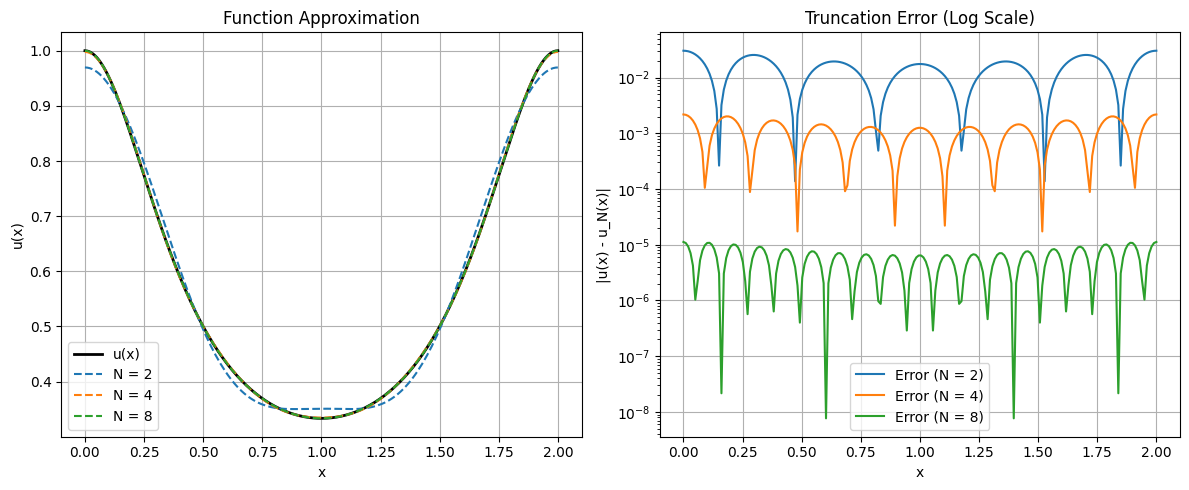

In [14]:
import matplotlib.pyplot as plt

u_k = lambda k: 1 / (np.sqrt(3) * (2 + np.sqrt(3))**np.abs(k))

def u_N(x, N):
    approx = np.zeros_like(x, dtype=complex)
    
    for k in range(-N, N + 1):
        term = u_k(k) * np.exp(1j * k * np.pi * x)
        
        approx += term
    
    return np.real(approx)

x = np.linspace(0, 2, 200)

approx_N2 = u_N(x, 2)
approx_N2 = u_N(x, 4)
approx_N2 = u_N(x, 8)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(x, u(x), 'k-', linewidth=2, label='u(x)')
for N in [2, 4, 8]:
    ax1.plot(x, u_N(x, N), '--', label=f'N = {N}')
ax1.set_title("Function Approximation")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x)")
ax1.legend()
ax1.grid(True)

for N in [2, 4, 8]:
    error = np.abs(u(x) - u_N(x, N))
    ax2.plot(x, error, label=f'Error (N = {N})')
ax2.set_title("Truncation Error (Log Scale)")
ax2.set_xlabel("x")
ax2.set_ylabel("|u(x) - u_N(x)|")
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### subpart b)

We recall the discrete fourier transform method;
$$
    \tilde{u}_k = \frac{1}{N} \sum_{j=0}^{N-1} u(x_j) e^{-i k \pi x_j}
$$
And plot for each $N$-value the absolute difference between $\hat{u}(x)$ and $\tilde{u}_k$

In [15]:
def u_discrete(k, N):
    j = np.arange(N)
    
    x_j = j * (2/N)
    
    return (1/N) * np.sum((u(x_j) * np.exp(-1j * k * np.pi * x_j)))

exact_coeff_k2 = u_k(2)
print(f"Exact Continuous Coefficient for k=2: {exact_coeff_k2:.6f}\n")

print("N  | Discrete Coeff | Error (Absolute Difference)")
print("-------------------------------------------------")

for N in [4, 8, 16, 32, 64]:
    approx_coeff = u_discrete(2, N)
    
    error = np.abs(exact_coeff_k2 - approx_coeff)
    
    print(f"{N:<2} | {np.real(approx_coeff):.6f}       | {error:.2e}")

Exact Continuous Coefficient for k=2: 0.041452

N  | Discrete Coeff | Error (Absolute Difference)
-------------------------------------------------
4  | 0.083333       | 4.19e-02
8  | 0.041667       | 2.15e-04
16 | 0.041452       | 5.71e-09
32 | 0.041452       | 4.14e-17
64 | 0.041452       | 4.22e-17


As we know from subpart a) the continuous Fourier coefficients $\hat{u}_k$ have exponential decay as the frequency $k$ increases. And due to aliasing on this grid from 0 to 2 of $N$ points, the discrete Fourier coefficient $\tilde{u}_k$ is not only equal to $\hat{u}_k$ but also the sum of every other high frequency aliases, $\hat{u}_{k+mN}$ for $m \in \mathbb{Z}$. This mechanism gives us that the lower the $N$ value, the higher the disturbance of the aliases are. As we see when $N=4$, the main contributor to noise is consequently $\hat{u}_{2 + 1 \cdot 4}$ which is way larger than for $N=16$, i.e. $\hat{u}_{2 + 1 \cdot 4} >> \hat{u}_{2 + 1 \cdot 16}$. So in conclusion, the aliasing error term vanishes exponentially such that the discrete coefficient converges to the exact continuous coefficient.